L05: example of application of the Maximum Likelihhod technique to estimate the mean of a gaussian
from a set of measurements

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import scipy.stats

In [ ]:
#hardcoding the likelihood function
def likelihood (data, mu, sigma):
    gauss = scipy.stats.norm(mu, sigma)
    L = 1.
    if isinstance(data, np.float64): #for data sets containing only one measurement
        return gauss.pdf(data)
    else:
        for x_i in data:
            L = L*gauss.pdf(x_i) # product of the probabilities
        return L

 #function giving back the log of the likelihood, given a proposed m and a given data set   
def loglikelihood (data, mu, sigma):
    gauss = scipy.stats.norm(mu, sigma)
    logL = 0.
    for x_i in data:
        logL = logL + gauss.logpdf(x_i)
    return logL

In [3]:
#defining the parameters of the true distribtuion and generating the data sample from it
mu = 1.
sigma = 0.2
N = 10
h = scipy.stats.norm(mu, sigma)
data = h.rvs(N) #sample

mu_grid = np.linspace(0.5, 1.5, 10000) #set of proposed mu values (of which we consider the Likelihood a function)

For practice, let's first work with the likelihood function itself

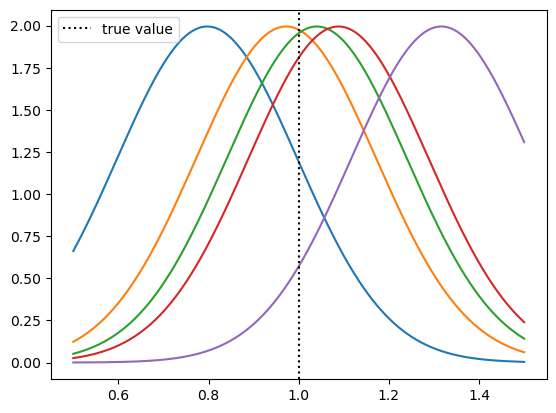

In [4]:
#plotting the likelihood as a function of mu for the individual data points
for x_i in data[:5]:
    mu_likelihood_1e = likelihood(x_i, mu_grid, sigma)
    plt.plot(mu_grid, mu_likelihood_1e)
plt.axvline(mu, c='black', ls='dotted', label='true value')
plt.legend()

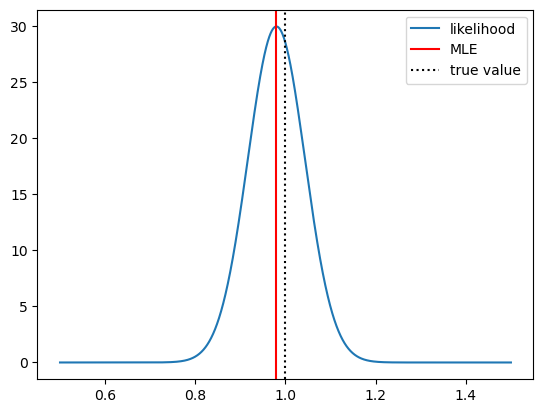

In [5]:
#evaluating the likelihood as a function of mu for the entire data set
mu_likelihood = likelihood(data, mu_grid, sigma)
sorted_entries = np.argsort(mu_likelihood) #sorting the positions of the array according to the associated value

MLE = mu_grid[sorted_entries[len(sorted_entries)-1]] #proposed value of mu which maximises the likelihood

#plotting the likelihood, aling with the MLE and the true value of the parameter
plt.plot(mu_grid, mu_likelihood, label='likelihood')
plt.axvline(MLE, c='r', label='MLE')
plt.axvline(mu, c='black', ls='dotted', label='true value')
plt.legend()


Now, let's work with the logLikelihood

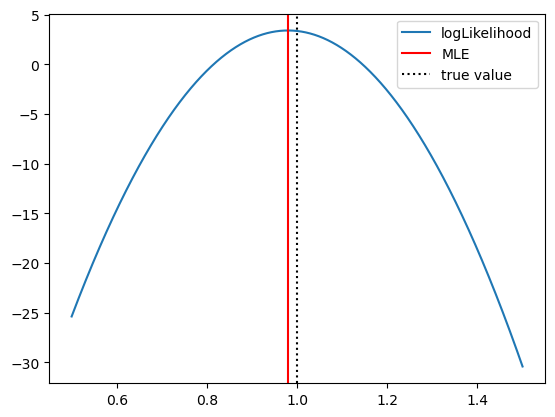

In [ ]:
#we follow the same steps as above but with the log of the likelihood
mu_loglik = loglikelihood(data, mu_grid, sigma)
sorted_log = np.argsort(mu_loglik)

index = len(sorted_log)-1
MLE_log = mu_grid[sorted_log[index]]

plt.plot(mu_grid, mu_loglik, label='logLikelihood')
plt.axvline(MLE_log, c='red', label='MLE')
plt.axvline(mu, c='black', ls='dotted', label='true value')
plt.legend()

Now, for a gaussian, the MLE for the population mean is equal to the sample mean. Also to maximize the likelihood is the same as to maximise it's log. Let's check this: 

In [9]:
sample_mean = np.mean(data)
print('The sample mean is equal to: ' + str(sample_mean))
print('The MLE for the mean is equal to: ' + str(MLE))
print('The MLE for the mean (from loglikelihood) is equal to: ' + str(MLE_log))

The sample mean is equal to: 0.9798644810417008
The MLE for the mean is equal to: 0.9798479847984798
The MLE for the mean (from loglikelihood) is equal to: 0.9798479847984798


For the uncertainty we compute the Fisher information matrix element

In [ ]:
#computing the second derivative of the loglikelihood
d_mu = mu_grid[1]-mu_grid[0]
dlogL_dmu = np.diff(mu_loglik)/d_mu
d2logL_dmu2 = np.diff(dlogL_dmu)/d_mu

F = -d2logL_dmu2[sorted_log[index]] #Fisher information matrix element
err = np.sqrt(1/F) #error associated to the MLE

sample_mean_err = sigma/np.sqrt(N) #for a gaussian should be equal to err on the MLE

print('The error is equal to: '+str(err))
print('The error on the sample mean is equal to: '+str(sample_mean_err))


The error is equal to: 0.06324555318669102
The error on the sample mean is equal to: 0.06324555320336758


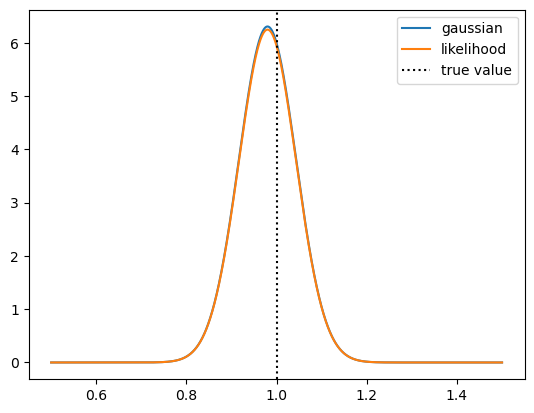

In [ ]:
gauss = scipy.stats.norm(MLE, err)

plt.plot(mu_grid, gauss.pdf(mu_grid), label='gaussian')
plt.plot(mu_grid, mu_likelihood/4.8, label='likelihood') #rescaling factor needed to normalize the likelihood
plt.axvline(mu, c='black', ls='dotted', label='true value')
plt.legend()

As expected, for N sufficiently large, the likelihood function approaches a gaussian centered on the MLE and with sigma equal to its uncertainty 